In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import sys 
import json 

In [16]:
data = pd.read_csv('../data/supply_raw_1month.csv', index_col=0)

In [17]:
data['block_start_time'] = pd.to_datetime(data['block_start_time'])
data['block_end_time'] = pd.to_datetime(data['block_end_time'])


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813587 entries, 0 to 813586
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   block_start_time  813587 non-null  datetime64[ns]
 1   block_end_time    813587 non-null  datetime64[ns]
 2   hex_id            813587 non-null  object        
 3   vehicle_type      813587 non-null  object        
 4   suppliers_online  813587 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 37.2+ MB


In [10]:
data.head(4)

,block_start_time,block_end_time,hex_id,vehicle_type,suppliers_online
0,2026-02-28 23:50:00,2026-03-01 00:00:00,8765b565bffffff,VAN-1000,1
1,2026-03-01 00:00:00,2026-03-01 00:10:00,8765b1914ffffff,VAN-500,1
2,2026-03-01 00:00:00,2026-03-01 00:10:00,8765b1930ffffff,VAN-1000,1
3,2026-03-01 00:00:00,2026-03-01 00:10:00,8765b1932ffffff,TRUCK-1000,1


#### 1/ Feature Engineering: 

In [15]:
#### Encoding vehicle type: 
data = pd.get_dummies(data, columns=['vehicle_type'])
data.head(2)

,block_start_time,block_end_time,hex_id,suppliers_online,day_of_week,hour_of_day,is_weekend,is_peak,vehicle_type_PICKUP-TRUCK,vehicle_type_TRICYCLE,vehicle_type_TRUCK-1000,vehicle_type_TRUCK-1500,vehicle_type_TRUCK-2000,vehicle_type_TRUCK-500,vehicle_type_VAN-1000,vehicle_type_VAN-500
0,2026-02-28 23:50:00,2026-03-01 00:00:00,8765b565bffffff,1,5,23,True,0,False,False,False,False,False,False,True,False
1,2026-03-01 00:00:00,2026-03-01 00:10:00,8765b1914ffffff,1,6,0,True,0,False,False,False,False,False,False,False,True


In [48]:
## Add lag, avm features: 
def feature_engineering(df):
    df = data.copy()

    # convert to datetime
    df['block_start_time'] = pd.to_datetime(df['block_start_time'])
    df['block_end_time'] = pd.to_datetime(df['block_end_time'])

    df['date'] = df['block_start_time'].dt.date

    # sort (VERY IMPORTANT for lag)
    df = df.sort_values('block_start_time')

    # ========================
    # 1. Time-based features
    # ========================

    df['month'] = df['block_start_time'].dt.month
    df['weekday'] = df['block_start_time'].dt.weekday   # Monday=0
    df['hour'] = df['block_start_time'].dt.hour

    # week of month
    df['week_of_month'] = df['block_start_time'].apply(
        lambda x: (x.day - 1) // 7 + 1
    )

    # ========================
    # 2. Lag features
    # ========================

    # IMPORTANT: group by date if each day is independent
    df['lag_1'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(1)

    df['lag_2'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(2)
    df['lag_3'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(3)
    df['lag_6'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(6)
    df['lag_144'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(144)  
    df['lag_143'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online'].shift(143) 


    df['diff_2'] = df['lag_1'] - df['lag_2']

    df['ma_3'] = (
        df.groupby(['hex_id','vehicle_type'])['suppliers_online']
        .transform(lambda x: x.shift(1).rolling(3).mean())
    )

    df['ma_6'] = (
        df.groupby(['hex_id','vehicle_type'])['suppliers_online']
        .transform(lambda x: x.shift(1).rolling(6).mean())
    )

    #detect abnormal spike:
    df['ratio_to_mean'] = df['lag_1'] / (df['ma_6'] + 1e-5)

    df['std_3'] = df.groupby(['hex_id','vehicle_type'])['suppliers_online']\
                    .transform(lambda x: x.shift(1).rolling(3).std())

    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)


    # define peak condition
    df['is_peak'] = (
        ((df['hour'] >= 8) & (df['hour'] < 11)) | #add 8AM for capture orders in pre-preak hour 
        ((df['hour'] >= 13) & (df['hour'] < 15))
    ).astype(int)

    # df_encode  = pd.get_dummies(df, columns=['vehicle_type'])
    # df_encode['vehicle_type'] = df['vehicle_type']

    return df

In [49]:
def impute_missing_values(data):
    df = data.copy()
    FEATURES = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_144',
    'lag_143',
    'diff_2',
    'ma_3',
    'ma_6',
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos', 
    ]

    df = df.sort_values(['hex_id', 'block_start_time'])

    df[FEATURES] = df.groupby('hex_id')[FEATURES].transform(lambda x: x.ffill())

    df_final = df.dropna().reset_index(drop=True)

    return df_final 


In [50]:
data_engin = feature_engineering(data)
data_engin = impute_missing_values(data_engin)
data_engin.head(4)

,block_start_time,block_end_time,hex_id,vehicle_type,suppliers_online,date,month,weekday,hour,week_of_month,...,diff_2,ma_3,ma_6,ratio_to_mean,std_3,hour_sin,hour_cos,weekday_sin,weekday_cos,is_peak
0,2026-03-03 04:50:00,2026-03-03 05:00:00,8765b1812ffffff,TRUCK-2000,1,2026-03-03,3,1,4,1,...,0.0,1.0,1.0,0.99999,0.0,0.866025,0.500000,0.781831,0.62349,0
1,2026-03-03 05:00:00,2026-03-03 05:10:00,8765b1812ffffff,TRUCK-2000,1,2026-03-03,3,1,5,1,...,0.0,1.0,1.0,0.99999,0.0,0.965926,0.258819,0.781831,0.62349,0
2,2026-03-03 05:10:00,2026-03-03 05:20:00,8765b1812ffffff,TRUCK-2000,1,2026-03-03,3,1,5,1,...,0.0,1.0,1.0,0.99999,0.0,0.965926,0.258819,0.781831,0.62349,0
3,2026-03-03 05:20:00,2026-03-03 05:30:00,8765b1812ffffff,TRUCK-2000,1,2026-03-03,3,1,5,1,...,0.0,1.0,1.0,0.99999,0.0,0.965926,0.258819,0.781831,0.62349,0


In [51]:
data_engin = pd.get_dummies(data_engin, columns=['vehicle_type'])
data_engin.head(4)

,block_start_time,block_end_time,hex_id,suppliers_online,date,month,weekday,hour,week_of_month,lag_1,...,weekday_cos,is_peak,vehicle_type_PICKUP-TRUCK,vehicle_type_TRICYCLE,vehicle_type_TRUCK-1000,vehicle_type_TRUCK-1500,vehicle_type_TRUCK-2000,vehicle_type_TRUCK-500,vehicle_type_VAN-1000,vehicle_type_VAN-500
0,2026-03-03 04:50:00,2026-03-03 05:00:00,8765b1812ffffff,1,2026-03-03,3,1,4,1,1.0,...,0.62349,0,False,False,False,False,True,False,False,False
1,2026-03-03 05:00:00,2026-03-03 05:10:00,8765b1812ffffff,1,2026-03-03,3,1,5,1,1.0,...,0.62349,0,False,False,False,False,True,False,False,False
2,2026-03-03 05:10:00,2026-03-03 05:20:00,8765b1812ffffff,1,2026-03-03,3,1,5,1,1.0,...,0.62349,0,False,False,False,False,True,False,False,False
3,2026-03-03 05:20:00,2026-03-03 05:30:00,8765b1812ffffff,1,2026-03-03,3,1,5,1,1.0,...,0.62349,0,False,False,False,False,True,False,False,False


### Trying baseline: 

In [58]:
# make sure sorted
def split_train_test_time(data, ratio, peak):

    df = data.copy()

# df_train = df[['order_date','total_demands','month','weekday','hour','week_of_month','lag_1','lag_2','lag_3','ma_3','std_3','is_peak']]
    df_train = df[df['is_peak']==peak].sort_values(['block_start_time'])

    # get unique dates
    dates = df_train['date'].sort_values().unique()

    # 80% train, 20% test
    split_idx = int(len(dates) * ratio)

    train_dates = dates[:split_idx]
    test_dates = dates[split_idx:]

    # split dataset
    train_df = df_train[df_train['date'].isin(train_dates)]
    test_df = df_train[df_train['date'].isin(test_dates)]

    print(train_df['date'].min(), "→", train_df['date'].max())
    print(test_df['date'].min(), "→", test_df['date'].max())

    return train_df, test_df

In [69]:
train_df, test_df = split_train_test_time(data_engin,0.8,1)

2026-03-02 → 2026-03-25
2026-03-26 → 2026-03-31


In [71]:
train_df.drop(columns = ['block_start_time','block_end_time','hex_id','date'],inplace=True)

In [73]:
X = train_df.drop(columns = ['suppliers_online'])
y = train_df['suppliers_online']

In [75]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

xgb_model_peak = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model_peak.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [76]:
X_test = test_df.drop(columns = ['block_start_time','block_end_time','hex_id','date','suppliers_online'])
y_test = test_df[['suppliers_online']]

y_pred = xgb_model_peak.predict(X_test)

In [77]:
def cal_smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

In [107]:
def wape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return (
        np.sum(np.abs(y_true - y_pred))
        / np.sum(np.abs(y_true))
    ) * 100

In [114]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2:", r2)
print("MSE:", mse)

wape_value = wape(y_test['suppliers_online'], y_pred)
print(wape_value)

R2: 0.7893949747085571
MSE: 1.1064189672470093


TypeError: 'numpy.float64' object is not callable

#### Optuna: 

In [80]:
import optuna

def objective(trial):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",

        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),

        "max_depth": trial.suggest_int("max_depth", 3, 12),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            1e-3,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-5,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-5,
            10,
            log=True
        ),
    }

    model = xgb.XGBRegressor(**params)

    model.fit(
        X,
        y,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    preds = model.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        preds,
        # squared=False
    )

    return rmse

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=50)

print(study.best_params)
print(study.best_value)

[I 2026-05-15 14:43:21,666] A new study created in memory with name: no-name-2ee38abb-a74b-4de5-9b0d-18a511b67da7
[I 2026-05-15 14:43:22,834] Trial 0 finished with value: 1.098656177520752 and parameters: {'n_estimators': 347, 'max_depth': 5, 'learning_rate': 0.028463549785874502, 'subsample': 0.6030483623024554, 'colsample_bytree': 0.8861187180206829, 'min_child_weight': 6, 'gamma': 1.8640881431773415, 'reg_alpha': 4.641313103129372e-05, 'reg_lambda': 5.58765380477907}. Best is trial 0 with value: 1.098656177520752.
[I 2026-05-15 14:43:23,569] Trial 1 finished with value: 1.1012109518051147 and parameters: {'n_estimators': 276, 'max_depth': 3, 'learning_rate': 0.02422903585903386, 'subsample': 0.7412905918812689, 'colsample_bytree': 0.5080297069757358, 'min_child_weight': 5, 'gamma': 0.7626635300695206, 'reg_alpha': 0.4144421389514365, 'reg_lambda': 0.8891402800670324}. Best is trial 0 with value: 1.098656177520752.
[I 2026-05-15 14:43:25,809] Trial 2 finished with value: 1.2675679922

{'n_estimators': 586, 'max_depth': 5, 'learning_rate': 0.008721941639161639, 'subsample': 0.7227501076309739, 'colsample_bytree': 0.9442343567677228, 'min_child_weight': 7, 'gamma': 0.3709500505475529, 'reg_alpha': 9.861653484150838e-05, 'reg_lambda': 0.00018119289750181557}
1.0973213911056519


In [81]:
xgb_best_model = xgb.XGBRegressor(**study.best_params)

xgb_best_model.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9442343567677228
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [82]:
y_pred_best = xgb_best_model.predict(X_test) 

r2 = r2_score(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)

print("R2:", r2)
print("MSE:", mse)

smape_value = cal_smape(y_test['suppliers_online'], y_pred_best)
print(smape_value)

R2: 0.7911266684532166
MSE: 1.0973213911056519
27.044668838626563


#### Evaluate Testing: 

In [84]:
test_df['y_pred'] = y_pred
test_df.head(3)

,block_start_time,block_end_time,hex_id,suppliers_online,date,month,weekday,hour,week_of_month,lag_1,...,is_peak,vehicle_type_PICKUP-TRUCK,vehicle_type_TRICYCLE,vehicle_type_TRUCK-1000,vehicle_type_TRUCK-1500,vehicle_type_TRUCK-2000,vehicle_type_TRUCK-500,vehicle_type_VAN-1000,vehicle_type_VAN-500,y_pred
343550,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b5644ffffff,2,2026-03-26,3,3,8,4,1.0,...,1,False,False,False,False,False,False,True,False,2.308126
360861,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b5646ffffff,4,2026-03-26,3,3,8,4,3.0,...,1,False,False,False,False,False,False,True,False,3.360703
9606,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b1912ffffff,1,2026-03-26,3,3,8,4,1.0,...,1,False,False,False,False,False,False,True,False,1.190249


In [95]:
test_df['date'] = pd.to_datetime(test_df['date'])

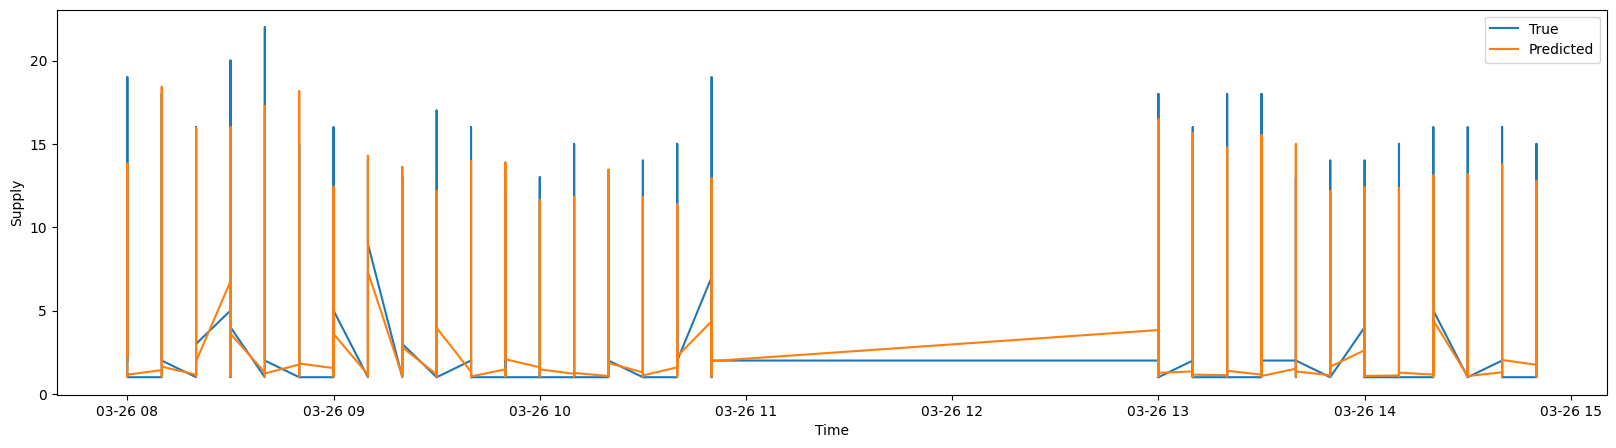

In [ ]:
# plot_df = test_df[test_df['hex_id']=='8765b5644ffffff']

# plot_df = test_df[test_df['vehicle_type_TRICYCLE']==True]
plot_df = test_df.copy()
plot_df = plot_df[plot_df['date']=='2026-03-26']

plt.figure(figsize=(20, 5))
plt.plot(plot_df['block_start_time'], plot_df['suppliers_online'], label='True')
plt.plot(plot_df['block_start_time'], plot_df['y_pred'], label='Predicted')
plt.xlabel('Time')
plt.ylabel('Supply')
plt.legend()
plt.show()

/var/folders/f5/j3qvvd4923z_49cvx7kg0qnh0000gn/T/ipykernel_16555/1452155227.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')


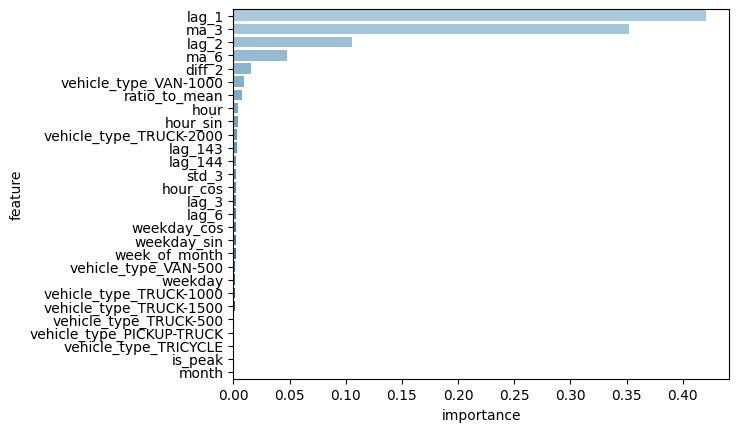

In [101]:
importance = xgb_model_peak.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feat_imp, palette='Blues_d')
plt.show()

#### Evaluate by vehicle type: 

In [102]:
test_df.head()

,block_start_time,block_end_time,hex_id,suppliers_online,date,month,weekday,hour,week_of_month,lag_1,...,is_peak,vehicle_type_PICKUP-TRUCK,vehicle_type_TRICYCLE,vehicle_type_TRUCK-1000,vehicle_type_TRUCK-1500,vehicle_type_TRUCK-2000,vehicle_type_TRUCK-500,vehicle_type_VAN-1000,vehicle_type_VAN-500,y_pred
343550,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b5644ffffff,2,2026-03-26,3,3,8,4,1.0,...,1,False,False,False,False,False,False,True,False,2.308126
360861,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b5646ffffff,4,2026-03-26,3,3,8,4,3.0,...,1,False,False,False,False,False,False,True,False,3.360703
9606,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b1912ffffff,1,2026-03-26,3,3,8,4,1.0,...,1,False,False,False,False,False,False,True,False,1.190249
316570,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b5640ffffff,1,2026-03-26,3,3,8,4,1.0,...,1,False,False,True,False,False,False,False,False,1.071896
92495,2026-03-26 08:00:00,2026-03-26 08:10:00,8765b1994ffffff,1,2026-03-26,3,3,8,4,1.0,...,1,False,False,False,False,False,False,True,False,1.190249
